In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./MNRAS.mplstyle')

import os
import h5py

In [2]:

# -----------------------------
# path to the Y-selected data
# -----------------------------

H5_FILE = "bias_data/wu22_eq8_Ysph_nsYcyl_selected_profiles_proj300_nscy_linear_with_sigg.h5" 

H5_FILE_3cmpch = "bias_data/wu22_eq8_Ycyl_selected_cyonly_proj3_nscy_linear_3cmpch.h5"

H5_FILE_60cmpch = "bias_data/wu22_eq8_Ycyl_selected_profiles_proj60_nscy_linear_with_sigg.h5"


def _decode_arr(arr):
    out = []
    for x in arr:
        if isinstance(x, (bytes, np.bytes_)):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return out


def load_ycyl_bias_file(path):
    """
    Read the single HDF5 written by calc_bias_flamingo_Ycyl_fixed.py only

    Returns
    -------
    rp : (Nrp,)
    survey_names : list[str]
    survey_counts : (4,)
    selection_names : list[str]
    observable_names : list[str]
    data : nested dict
        data[selection_name]["meta"][...]
        data[selection_name]["results"][observable][field]
    """
    data = {}

    with h5py.File(path, "r") as f:
        rp = f["rp"][:]
        survey_names = _decode_arr(f["survey_names"][:])
        survey_counts = f["survey_counts"][:]
        selection_names = _decode_arr(f["selection_names"][:])
        observable_names = _decode_arr(f["observable_names"][:])

        for sel in selection_names:
            data[sel] = {"meta": {}, "results": {}}

            gmeta = f[f"selection_sets/{sel}/meta"]
            for key in gmeta.keys():
                data[sel]["meta"][key] = gmeta[key][:]

            for obs in observable_names:
                g = f[f"selection_sets/{sel}/results/{obs}"]
                data[sel]["results"][obs] = {}
                for key in g.keys():
                    if key == "rp":
                        continue
                    data[sel]["results"][obs][key] = g[key][:]

    return rp, survey_names, survey_counts, selection_names, observable_names, data



rp, survey_names, survey_counts, selection_names, observable_names, ycyl_data = load_ycyl_bias_file(H5_FILE)

print("rp shape:", rp.shape)
print("survey_names:", survey_names)
print("survey_counts:", survey_counts)
print("selection_names:", selection_names)
print("observable_names:", observable_names)

print(60*"-")


_, survey_names, survey_counts, selection_names, observable_names, ycyl_data_3cmpch = load_ycyl_bias_file(H5_FILE_3cmpch)

# print("rp shape:", rp.shape)
print("survey_names:", survey_names)
print("survey_counts:", survey_counts)
print("selection_names:", selection_names)
print("observable_names:", observable_names)


print(60*"-")


_, survey_names, survey_counts, selection_names, observable_names, ycyl_data_60cmpch = load_ycyl_bias_file(H5_FILE_60cmpch)

# print("rp shape:", rp.shape)
print("survey_names:", survey_names)
print("survey_counts:", survey_counts)
print("selection_names:", selection_names)
print("observable_names:", observable_names)

rp shape: (20,)
survey_names: ['ACT_DR6', 'ACT_DR6_Legacy', 'SPT_SZ', 'SPTpol_500d']
survey_counts: [458 229 138 496]
selection_names: ['Y500c_true', 'Y5R500c_true', 'Y500c_so_baseline_noise', 'Y5R500c_so_baseline_noise']
observable_names: ['DS', 'Sigma', 'cy_true', 'cy_so_baseline_noise', 'Sigma_g_hd', 'Sigma_g_ld']
------------------------------------------------------------
survey_names: ['ACT_DR6', 'ACT_DR6_Legacy', 'SPT_SZ', 'SPTpol_500d']
survey_counts: [458 229 138 496]
selection_names: ['Y500c_true', 'Y5R500c_true', 'Y500c_so_baseline_noise', 'Y5R500c_so_baseline_noise']
observable_names: ['cy_true', 'cy_so_baseline_noise']
------------------------------------------------------------
survey_names: ['ACT_DR6', 'ACT_DR6_Legacy', 'SPT_SZ', 'SPTpol_500d']
survey_counts: [458 229 138 496]
selection_names: ['Y500c_true', 'Y5R500c_true', 'Y500c_so_baseline_noise', 'Y5R500c_so_baseline_noise']
observable_names: ['DS', 'Sigma', 'cy_true', 'cy_so_baseline_noise', 'Sigma_g_hd', 'Sigma_g_l

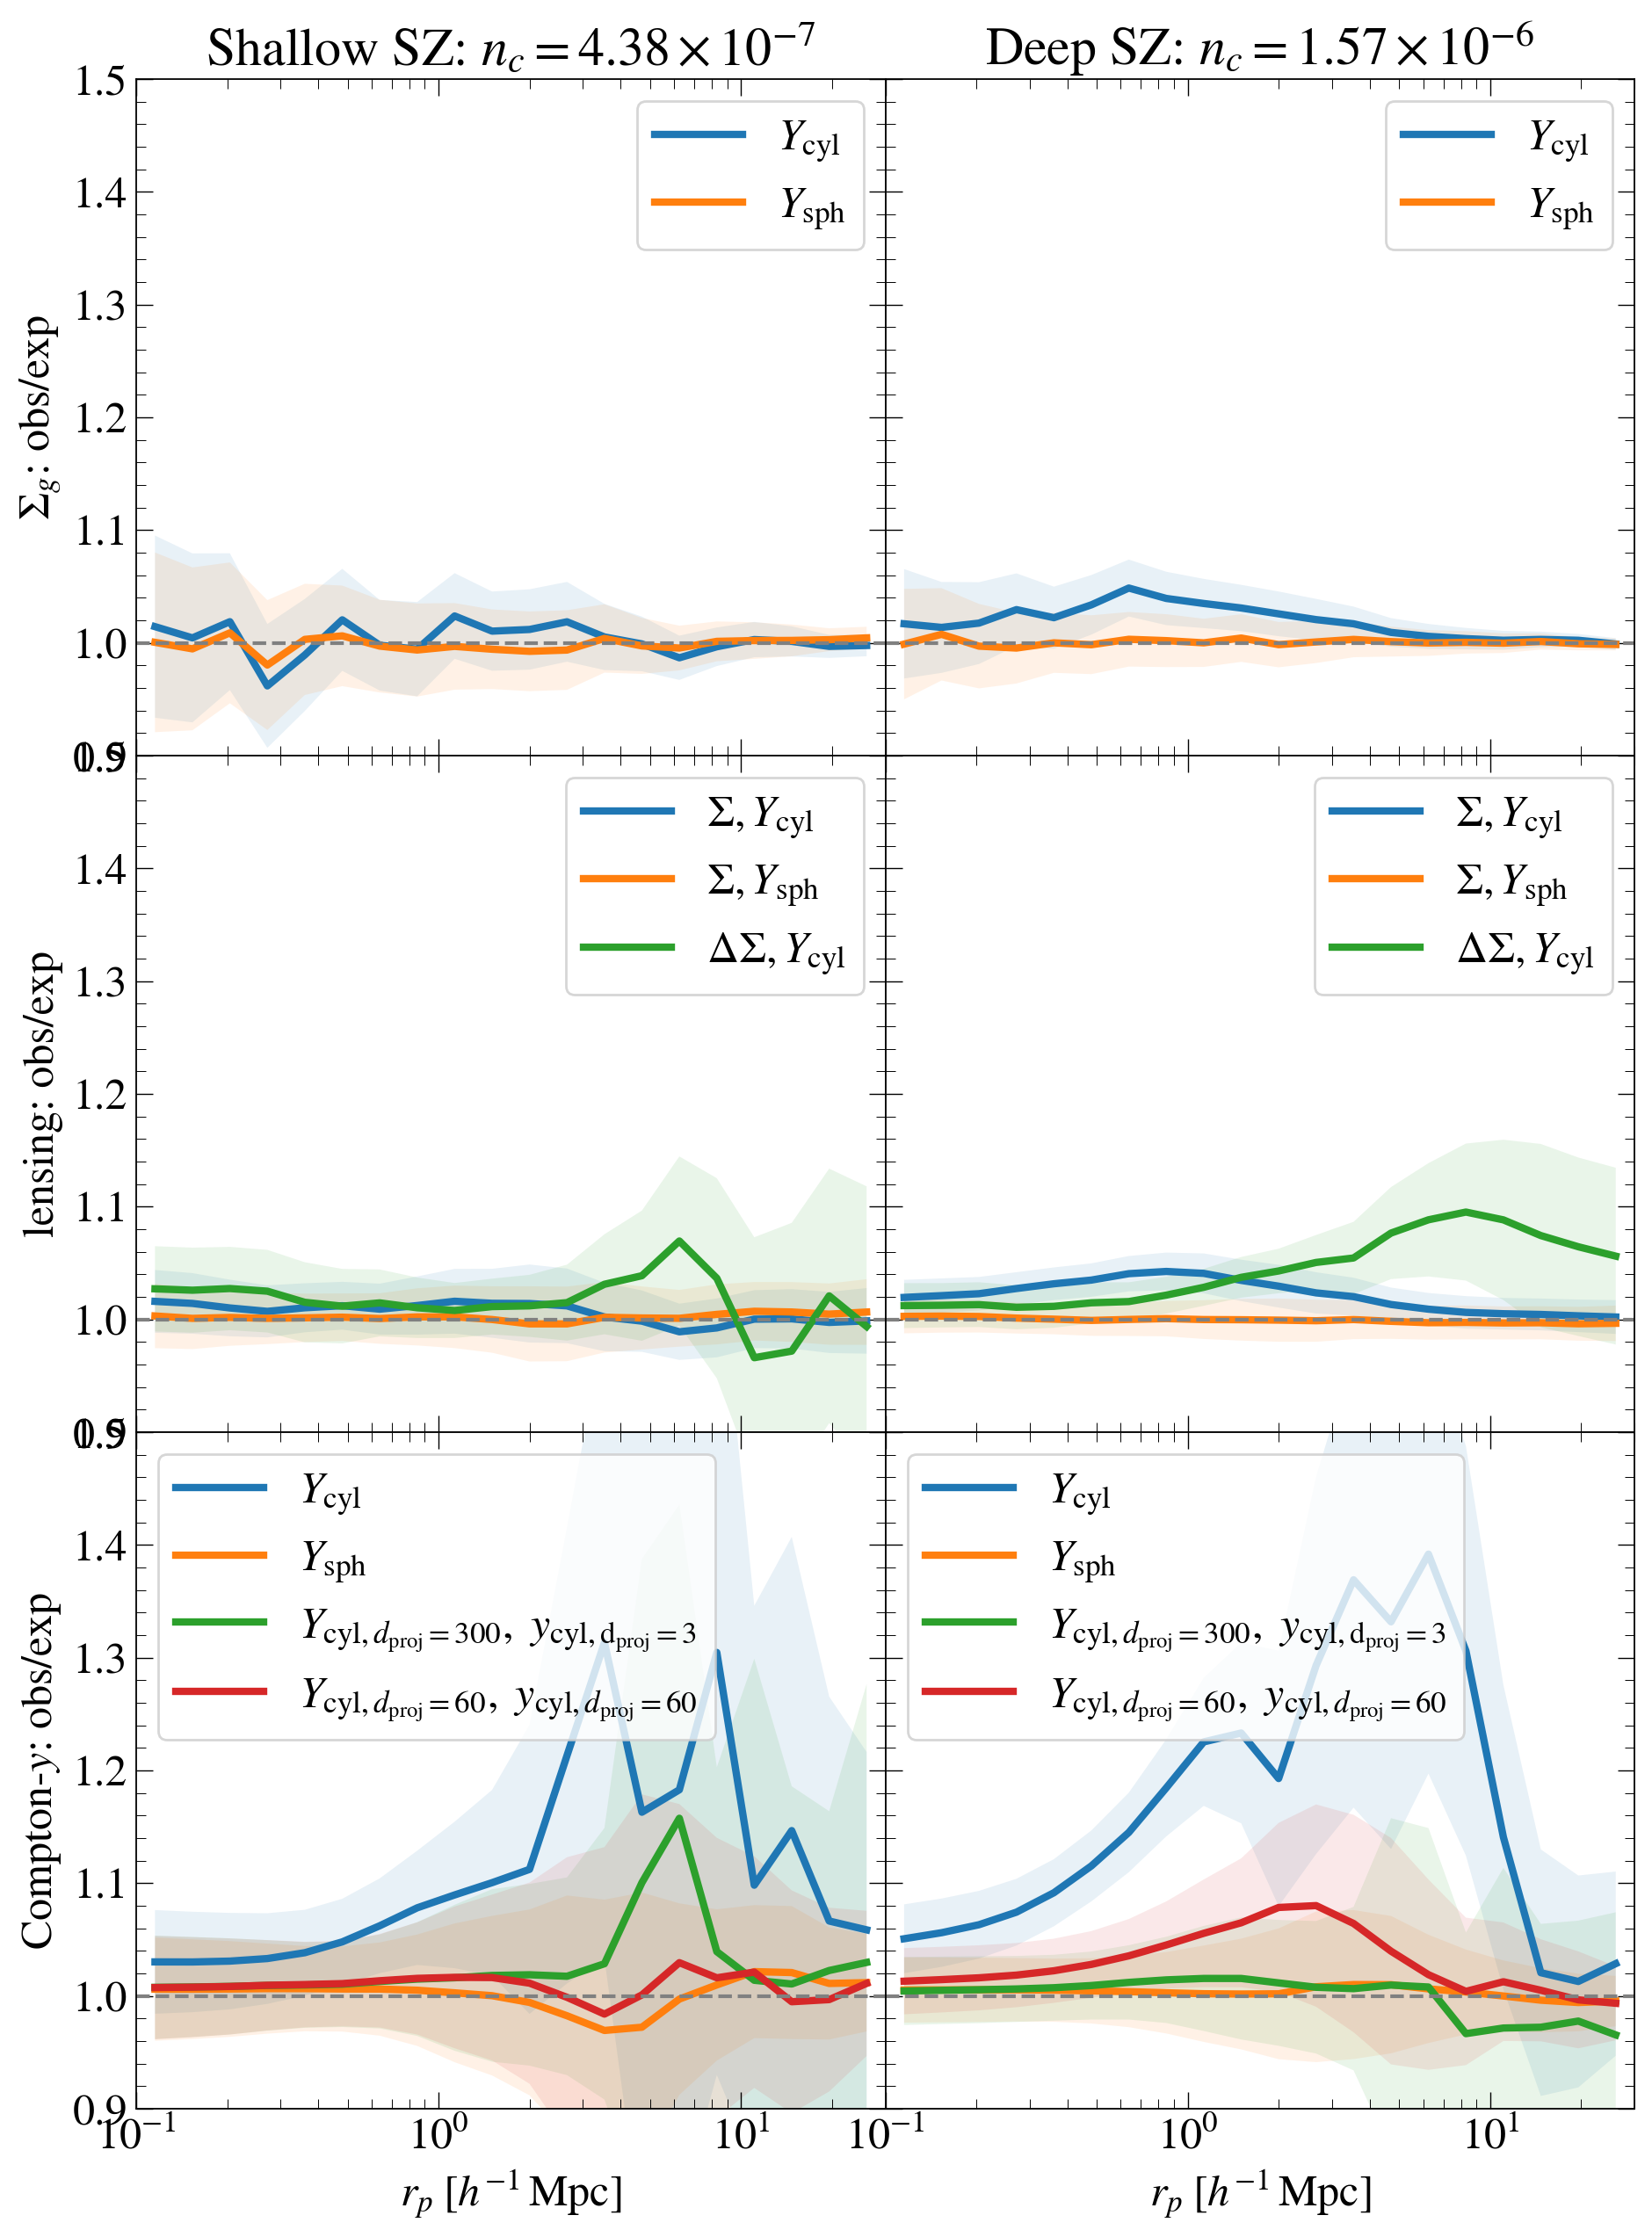

In [3]:
#### Y selected sample
# For Y_sph: use the value from SOAP
# Use n_g = 1e-2 for Sigma_g
# Fix projection depth for lensing and y


ncols = 2
nrows = 3

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5*ncols+1, 5*nrows),
    sharex=True,
    gridspec_kw = {'wspace':0, 'hspace':0}
    , sharey='row',
)

col_titles = [ # (cMpc/h)^3
    r"Shallow SZ: $n_c = 4.38\times10^{-7}$", #SPT-SZ like, 
    r"Deep SZ: $n_c = 1.57\times10^{-6}$",  # SPT-pol like, 
]

row_ylabels = [
    r"$\Sigma_g$: obs/exp",
    r"lensing: obs/exp",
    r"Compton-$y$: obs/exp",
]

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title)

for row, ylabel in enumerate(row_ylabels):
    axes[row, 0].set_ylabel(ylabel)

for col in range(ncols):
    axes[2, col].set_xlabel(r"$r_p \; [h^{-1}\,\mathrm{Mpc}]$")

for row in range(nrows):
    for col in range(ncols):
        ax = axes[row, col]
        survey_idx = col+2 ### 2 for SPT-SZ, 3 for SPTpol-500d
        
        if row == 0:  # galaxy distribution
            
            # rp = np.geomspace(0.1, 30) #### TODO: placeholder
            # S = 0.1*rp+1 #### placeholder
            # dS = 0.05 #### placeholder

            # Y_selector_name = ["Y500c_true",  "Y5R500c_true", "Y500c_so_baseline_noise", "Y5R500c_so_baseline_noise"]
            # obs_name        = ["DS", "Sigma", "cy_true", "cy_so_baseline_noise", "Sigma_g_hd", "Sigma_g_ld"]
            
            
            y_sim = ycyl_data["Y500c_so_baseline_noise"]["results"]["Sigma_g_hd"]["bias_sim"][survey_idx, :]
            e_sim = ycyl_data["Y500c_so_baseline_noise"]["results"]["Sigma_g_hd"]["bias_sim_err"][survey_idx, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$Y_{\rm cyl}$")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

            
            ### Y500c_true == Ysph(from Flamingo data-SOAP)-selected 
            y_sim = ycyl_data["Y500c_true"]["results"]["Sigma_g_hd"]["bias_sim"][survey_idx, :]
            e_sim = ycyl_data["Y500c_true"]["results"]["Sigma_g_hd"]["bias_sim_err"][survey_idx, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$Y_{\rm sph}$")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
            
        if row == 1:  # lensing

            y_sim = ycyl_data["Y500c_so_baseline_noise"]["results"]["Sigma"]["bias_sim"][survey_idx, :]
            e_sim = ycyl_data["Y500c_so_baseline_noise"]["results"]["Sigma"]["bias_sim_err"][survey_idx, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$\Sigma, Y_{\rm cyl}$")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

            
            y_sim = ycyl_data["Y500c_true"]["results"]["Sigma"]["bias_sim"][survey_idx, :]
            e_sim = ycyl_data["Y500c_true"]["results"]["Sigma"]["bias_sim_err"][survey_idx, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$\Sigma, Y_{\rm sph}$")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

            
            y_sim = ycyl_data["Y500c_so_baseline_noise"]["results"]["DS"]["bias_sim"][survey_idx, :]
            e_sim = ycyl_data["Y500c_so_baseline_noise"]["results"]["DS"]["bias_sim_err"][survey_idx, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$\Delta\Sigma, Y_{\rm cyl}$") # no Ysph to avoid clutter
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

        if row == 2:  # SZ

            y_sim = ycyl_data["Y500c_so_baseline_noise"]["results"]["cy_so_baseline_noise"]["bias_sim"][survey_idx, :]
            e_sim = ycyl_data["Y500c_so_baseline_noise"]["results"]["cy_so_baseline_noise"]["bias_sim_err"][survey_idx, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$Y_{\rm cyl}$")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)


            y_sim = ycyl_data["Y500c_true"]["results"]["cy_true"]["bias_sim"][survey_idx, :]
            e_sim = ycyl_data["Y500c_true"]["results"]["cy_true"]["bias_sim_err"][survey_idx, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$Y_{\rm sph}$")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
        
            ### Add proj_depth = 60/3 cMpc/h for Y, cy w/o noise

            y_sim = ycyl_data_3cmpch["Y500c_true"]["results"]["cy_true"]["bias_sim"][survey_idx, :]
            e_sim = ycyl_data_3cmpch["Y500c_true"]["results"]["cy_true"]["bias_sim_err"][survey_idx, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$Y_{\rm cyl,\it d_{\rm proj}=300},~y_{\rm cyl, d_{\rm proj}=3}$")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)

            y_sim = ycyl_data_60cmpch["Y500c_true"]["results"]["cy_true"]["bias_sim"][survey_idx, :]
            e_sim = ycyl_data_60cmpch["Y500c_true"]["results"]["cy_true"]["bias_sim_err"][survey_idx, :]
            
            line = ax.plot(rp, y_sim, lw=3, label=r"$Y_{\rm cyl,\it d_{\rm proj}=60},~y_{\rm cyl, \it d_{\rm proj}=60}$")
            ax.fill_between(rp, y_sim-e_sim, y_sim+e_sim, interpolate=True, facecolor=line[0].get_c(), alpha=0.1)
            
        
        ax.axhline(1, c='gray', ls='--')
        ax.set_ylim(0.9, 1.5)
        ax.set_xlim(0.1, 30)
        ax.set_xscale('log')        
        ax.legend()
        ax.grid(False)
#plt.savefig('../plots/Y_selection.pdf')

In [4]:
# When calculating obs/exp, the models I used for different observables with KLLR:
# profiles = {
#     "DS": ds_ranked,
#     "Sigma": sigma_ranked,
#     "cy_true": cy_true_ranked,
#     "cy_so_baseline_noise": cy_noise_ranked,
#     "Sigma_g_hd": sigg_hd_ranked,
#     "Sigma_g_ld": sigg_ld_ranked,
# }
# y_modes = {
#     "DS": "linear",
#     "Sigma": "log",
#     "cy_true": "log",
#     "cy_so_baseline_noise": "linear",
#     "Sigma_g_hd": "linear",
#     "Sigma_g_ld": "linear",
# }